### **imports**

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
from pathlib import Path
from functools import partial

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import cmasher as cmr
from varname import argname # for checking variable name when plotting

### **loading in data and data prep**

##### **loading in .nc files**

loading in .nc files, extracting the integrated gradient dimension, averaging across result batches and long/lat to give variable importance values for each unique year combo and variable

In [2]:
# Define lat/lon ranges and region name for entire notebook
lat_start, lat_end = input("Enter latitude range with each integer value separated by a comma. Do not use spaces or any other characters. If entire globe desired, enter '0,0'.") \
    .split(',')
lat_range = (int(lat_start), int(lat_end))

lon_start, lon_end = input("Enter longitude range with each integer value separated by a comma. Do not use spaces or any other characters. If entire globe desired, enter '0,0'.") \
    .split(',')
lon_range = (int(lon_start), int(lon_end))

region = input("Which region do these ranges correspond to? If entire globe, enter nothing.")

In [10]:
print(lat_range)
print(type(lat_range))

print(lon_range)
print(type(lon_range))

(0, 0)
<class 'tuple'>
(0, 0)
<class 'tuple'>


In [19]:
def load_nc_tryinglatlonrange(do_mean, abs_val, lat_range=lat_range, lon_range=lon_range):

    # A flag to take the mean or not (different types of variable importance, IG completeness property)
    do_mean = do_mean.lower().strip()

    # A flag to take abs val or not for different ways of interpreting variable importance
    abs_val = abs_val.lower().strip()


    # getting directory for the result batches nc files 
    parent_dir = Path.cwd() / "climate_experiments" 

    # initializing dictionary for folder file counts to ensure each folder (differentiated as folder paths) has same number of folder items 
    folder_file_counts = {}

    # going thru directory to find any folders that start with result_batches (by the glob) & going thru it alphabetically (by the sorted)
    for run_folder in sorted(parent_dir.glob("result_batches*")):
        # is_dir() to ensure that result_batches is actually a folder, not like a nc file or something idk 
        if run_folder.is_dir():
            # turning all the nc files in that folder into a list 
            nc_files = list(run_folder.glob("*.nc"))
            # if there are actually files in the folder
            if nc_files: 
                # count number of files in the folder and store that in the dictionary
                folder_file_counts[run_folder] = len(nc_files)

    # error handling if all the folders are empty 
    if not folder_file_counts:
        raise ValueError("no nc files in the folder!")


    # finding max number of file counts (should be 56/57) -- complete run length
    dynamic_expected = max(folder_file_counts.values())
    print(f"max is {dynamic_expected} files")


    # initializie list that will hold the arrays from every run 
    all_runs_data = []

    # going through each folder and looking at the files and the count of the files in the folder
    for run_folder, count in folder_file_counts.items():

        # if the count of the files in the run folder does not equal 56/57 
        if count != dynamic_expected:
            print(f"skip{run_folder.name} bc only {count} files, expected {dynamic_expected}")
            # keep going to the next folder and don't save the folder that doesn't have right amount of files 
            continue
        
        # saving the nc files in chrnological order (via sorted)
        nc_files = sorted(list(run_folder.glob("*.nc")))

        
        # opening the files in the folder
            # concat_dim = yr_combo --> creates new dimension to stack all the arrays tg 
            # combine = nested --> just stack in the order that files are alr in since alr sorted (computationally more efficient)
        
        # ----------------------- If lat, lon given are None ---------------------------------------
        # with no lat/lon ranges:
        if lat_range == (0,0) and lon_range == (0,0) :

            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
        

        # ----------------------- If lat/lon range given ---------------------------------------
        else:

            def _preprocess(x, lon_bnds, lat_bnds):
                return x.sel(lon=slice(*lon_bnds), lat=slice(*lat_bnds))

            partial_func = partial(_preprocess, lon_bnds=lon_range, lat_bnds=lat_range)
            
            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', preprocess=partial_func, combine='nested') 
 

        # extracting integrated gradient maps from nc file
        run_data = run_ds['ig_heatmaps'].values
            # run_data shape --> (56, 25, 144, 73, 6)
        
        
        # ----------------------- If do mean flag on ---------------------------------------
        if do_mean == 'yes':
                
                run_mean_samples = np.nanmean(np.abs(run_data), axis=1, dtype=np.float64) if abs_val == 'yes' else np.nanmean(run_data, axis=1, dtype=np.float64)

                # appending to list 
                all_runs_data.append(run_mean_samples)
              

        # ----------------------- If do mean flag off ---------------------------------------
        elif do_mean == 'no':

            all_runs_data.append(run_data)


        # --------------------- If flag entered improperly -----------------------------------
        else:
            raise ValueError("Enter yes or no for each flag.") 


    # error handling if all folders do not have enough items 
    if not all_runs_data:
        raise ValueError("none of the folders have enough nc files")

    # stacking all the averaged heatmaps 
    return np.stack(all_runs_data), run_ds


# master_phi_matrix = load_nc_tryinglatlonrange(do_mean='yes', abs_val='no')
# abs_val_phi_matrix = load_nc_tryinglatlonrange(do_mean='yes', abs_val='yes')

# print(master_phi_matrix.shape)
# print(abs_val_phi_matrix.shape)

In [ ]:
#completeness_property_phi_matrix = load_nc_tryinglatlonrange(do_mean='no', abs_val='no')

In [21]:
def load_nc(do_mean, abs_val, lat_range=None, lon_range=None):

    # A flag to take the mean or not (different types of variable importance, IG completeness property)
    do_mean = do_mean.lower().strip()

    # A flag to take abs val or not for different ways of interpreting variable importance
    abs_val = abs_val.lower().strip()


    # getting directory for the result batches nc files 
    parent_dir = Path.cwd() / "climate_experiments" 

    # initializing dictionary for folder file counts to ensure each folder (differentiated as folder paths) has same number of folder items 
    folder_file_counts = {}

    # going thru directory to find any folders that start with result_batches (by the glob) & going thru it alphabetically (by the sorted)
    for run_folder in sorted(parent_dir.glob("result_batches*")):
        # is_dir() to ensure that result_batches is actually a folder, not like a nc file or something idk 
        if run_folder.is_dir():
            # turning all the nc files in that folder into a list 
            nc_files = list(run_folder.glob("*.nc"))
            # if there are actually files in the folder
            if nc_files: 
                # count number of files in the folder and store that in the dictionary
                folder_file_counts[run_folder] = len(nc_files)

    # error handling if all the folders are empty 
    if not folder_file_counts:
        raise ValueError("no nc files in the folder!")


    # finding max number of file counts (should be 56/57) -- complete run length
    dynamic_expected = max(folder_file_counts.values())
    print(f"max is {dynamic_expected} files")


    # initializie list that will hold the arrays from every run 
    all_runs_data = []

    # going through each folder and looking at the files and the count of the files in the folder
    for run_folder, count in folder_file_counts.items():

        # if the count of the files in the run folder does not equal 56/57 
        if count != dynamic_expected:
            print(f"skip{run_folder.name} bc only {count} files, expected {dynamic_expected}")
            # keep going to the next folder and don't save the folder that doesn't have right amount of files 
            continue
        
        # saving the nc files in chrnological order (via sorted)
        nc_files = sorted(list(run_folder.glob("*.nc")))

        
        # opening the files in the folder
            # concat_dim = yr_combo --> creates new dimension to stack all the arrays tg 
            # combine = nested --> just stack in the order that files are alr in since alr sorted (computationally more efficient)
        
        # ----------------------- If no lat, lon given ---------------------------------------
        # with no lat/lon ranges:
        if not lat_range and not lon_range:

            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
        

        # ----------------------- If lat/lon range given ---------------------------------------
        elif lat_range and lon_range:

            def _preprocess(x, lon_bnds, lat_bnds):
                return x.sel(lon=slice(*lon_bnds), lat=slice(*lat_bnds))

            partial_func = partial(_preprocess, lon_bnds=lon_range, lat_bnds=lat_range)
            
            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', preprocess=partial_func, combine='nested') 
 

        # extracting integrated gradient maps from nc file
        run_data = run_ds['ig_heatmaps'].values
            # run_data shape --> (56, 25, 144, 73, 6)
        
        
        # ----------------------- If do mean flag on ---------------------------------------
        if do_mean == 'yes':
                
                run_mean_samples = np.nanmean(np.abs(run_data), axis=1, dtype=np.float64) if abs_val == 'yes' else np.nanmean(run_data, axis=1, dtype=np.float64)

                # appending to list 
                all_runs_data.append(run_mean_samples)
              

        # ----------------------- If do mean flag off ---------------------------------------
        elif do_mean == 'no':

            all_runs_data.append(run_data)


        # --------------------- If flag entered improperly -----------------------------------
        else:
            raise ValueError("Enter yes or no for each flag.") 


    # error handling if all folders do not have enough items 
    if not all_runs_data:
        raise ValueError("none of the folders have enough nc files")

    # stacking all the averaged heatmaps 
    return np.stack(all_runs_data), run_ds



master_phi_matrix, run_ds = load_nc(do_mean='yes', abs_val='no')
#abs_val_phi_matrix = load_nc(do_mean='yes', abs_val='yes')
# completeness_property_phi_matrix = load_nc(do_mean='no', abs_val='no')
#regional_phi_matrix = load_nc(do_mean='yes', abs_val='no', lat_range=(180,200), lon_range=(50,70)) # Can also toggle abs_val flag back on 


print(master_phi_matrix.shape)
print(abs_val_phi_matrix.shape)
print(completeness_property_phi_matrix.shape)
print(regional_phi_matrix.shape)

max is 56 files
(15, 56, 144, 73, 6)
(15, 56, 144, 73, 6)
(15, 56, 25, 144, 73, 6)
(73, 6, 144)


In [ ]:
x_axis_completeness = np.nansum(completeness_property_phi_matrix, axis=(3,4,5)).flatten()

In [ ]:
x_axis_completeness.shape

(21000,)

#### **making a df for yr combos and scenarios**

need unique yr combos and scenarios split up in differentiating way for easy discernment in plotting code 

In [5]:
def yr_scen_combo_df():    
    # providing folder example that has correct number of items (56/57)
    sample_folder = Path.cwd() / "climate_experiments" / "result_batchessophiekim_1" 
    print(sample_folder)
    # gets all the .nc files in chronological order 
    nc_files = sorted(list(sample_folder.glob("*.nc")))

    # initializing list
    data = []


    # looping through the .nc files to extract relevant info
    for idx, filepath in enumerate(nc_files):
        # getting filename from .stem -- just gives 'res_ssp119_2015_2025' as filename
        filename = filepath.stem 
        # splitting so that _ splits each word into diff strings rather than one big one 
            # [res, ssp119, 2015, 2025]
        parts = filename.split('_')
        print(parts)
        print(filename)
        
        # extracting relevant info from the parts var
        scenario_id = parts[1]
        early_yr = int(parts[-2]) # second to last 
        late_yr = int(parts[-1]) # last 
        
        # compliling all the info tg 
        data.append({
            'combo_idx': idx,
            'scenario': scenario_id,
            'early': early_yr,
            'late': late_yr
        })


    metadata_df = pd.DataFrame(data)

    return metadata_df

metadata_df = yr_scen_combo_df()

/Users/sophiekim/Desktop/2_research/MamalakisResearch/climate_experiments/result_batchessophiekim_1
['res', 'ssp119', '2015', '2025']
res_ssp119_2015_2025
['res', 'ssp119', '2015', '2035']
res_ssp119_2015_2035
['res', 'ssp119', '2015', '2045']
res_ssp119_2015_2045
['res', 'ssp119', '2015', '2055']
res_ssp119_2015_2055
['res', 'ssp119', '2015', '2065']
res_ssp119_2015_2065
['res', 'ssp119', '2015', '2075']
res_ssp119_2015_2075
['res', 'ssp119', '2015', '2085']
res_ssp119_2015_2085
['res', 'ssp119', '2025', '2035']
res_ssp119_2025_2035
['res', 'ssp119', '2025', '2045']
res_ssp119_2025_2045
['res', 'ssp119', '2025', '2055']
res_ssp119_2025_2055
['res', 'ssp119', '2025', '2065']
res_ssp119_2025_2065
['res', 'ssp119', '2025', '2075']
res_ssp119_2025_2075
['res', 'ssp119', '2025', '2085']
res_ssp119_2025_2085
['res', 'ssp119', '2035', '2045']
res_ssp119_2035_2045
['res', 'ssp119', '2035', '2055']
res_ssp119_2035_2055
['res', 'ssp119', '2035', '2065']
res_ssp119_2035_2065
['res', 'ssp119', '2

In [6]:
metadata_df

,combo_idx,scenario,early,late
0,0,ssp119,2015,2025
1,1,ssp119,2015,2035
2,2,ssp119,2015,2045
3,3,ssp119,2015,2055
4,4,ssp119,2015,2065
5,5,ssp119,2015,2075
6,6,ssp119,2015,2085
7,7,ssp119,2025,2035
8,8,ssp119,2025,2045
9,9,ssp119,2025,2055


#### **defining variables**

for plotting purposes, to discern out the 6 layers in the array dimension

In [7]:
# explicitly defining variables (order has to be exact as the .nc files)
climate_variables = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind"] # got order from the get_cnn_tensors file bc that is when X_data was prepped


# making dictionary so that legible var name appears in heatmaps
variable_dictionary = {
    "tas": "Mean Surface\nTemp",
    "tasmax": "Max Surface\nTemp",
    "tasmin": "Min Surface\nTemp",
    "pr": "Precipitation",
    "psl": "Sea Level\nPressure",
    "sfcWind": "Surface Wind\nSpeed"
}

# making new list 
    # making variables readable by replacing the original var for the value in variable dictionary via list comprehension
readable_variables = [variable_dictionary[var] for var in climate_variables]

print(readable_variables)

['Mean Surface\nTemp', 'Max Surface\nTemp', 'Min Surface\nTemp', 'Precipitation', 'Sea Level\nPressure', 'Surface Wind\nSpeed']


In [8]:
master_phi_matrix.shape

(15, 56, 144, 73, 6)

In [ ]:
# (lat, lon, vars)
regional_phi_matrix = np.nanmean(master_phi_matrix, axis=(0, 1))
regional_phi_matrix.shape

(144, 73, 6)

In [30]:
lat = run_ds.lat.values
lon = run_ds.lon.values

print(lat.shape)
print(lon)

(144,)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72]


### practice map pulled from model_and_plot_sk --> changed to fit this case

(144,)
(74,)
(144, 74)
Lat range: 0 to 143
Lonp range: -180.0 to 185.0
(144,)
(74,)
(144, 74)
Lat range: 0 to 143
Lonp range: -180.0 to 185.0
(144,)
(74,)
(144, 74)
Lat range: 0 to 143
Lonp range: -180.0 to 185.0
(144,)
(74,)
(144, 74)
Lat range: 0 to 143
Lonp range: -180.0 to 185.0
(144,)
(74,)
(144, 74)
Lat range: 0 to 143
Lonp range: -180.0 to 185.0
(144,)
(74,)
(144, 74)
Lat range: 0 to 143
Lonp range: -180.0 to 185.0


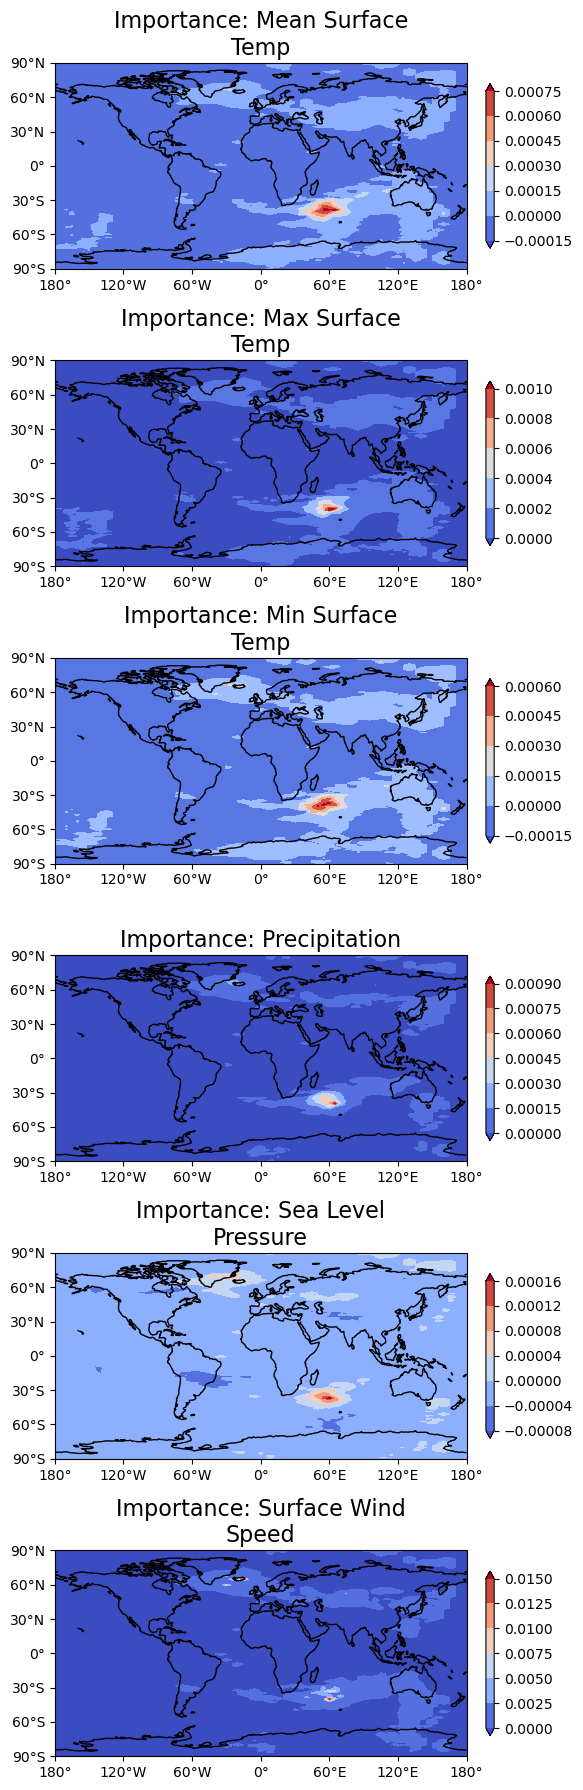

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

regional_phi_matrix = np.nanmean(master_phi_matrix, axis=(0, 1))

global_vmax = np.quantile(np.abs(regional_phi_matrix), 0.99)
if global_vmax <= 1e-12: global_vmax = 0.1

# need to define this? 
real_lat = np.linspace(-90, 90, 144) 
real_lon = np.linspace(-180, 180, 73)


num_vars = len(readable_variables)
fig = plt.figure(figsize=(10, 3 * num_vars))
if data_v.shape == (len(lon), len(lat)): data_v = data_v.T
for i in range(num_vars):

    ax = fig.add_subplot(num_vars, 1, i + 1, projection=ccrs.PlateCarree())
    
    
    data_v = regional_phi_matrix[:, :, i]
    
   
    samplep, lonp = add_cyclic_point(data_v, coord=real_lon)
    print(lat.shape)
    print(lonp.shape)
    print(samplep.shape)
    print(f"Lat range: {lat.min()} to {lat.max()}")
    print(f"Lonp range: {lonp.min()} to {lonp.max()}")
    # Plot
    cs = ax.contourf(lonp, real_lat, samplep, cmap="coolwarm", 
                     #levels=np.linspace(-global_vmax, global_vmax, 21), 
                     extend='both', transform=ccrs.PlateCarree())
    

    ax.coastlines()
    ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
    
    ax.set_title(f'Importance: {readable_variables[i]}', fontsize=16)
    plt.colorbar(cs, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)

plt.tight_layout()
plt.show()

In [ ]:
def plot_regional_importance(master_phi_matrix, lat, lon, var_list):
    """
    master_phi_matrix: (runs, combos, lat, lon, vars)
   
    """
    phi_data = np.nanmean(master_phi_matrix, axis=(0, 1))

    #
    phi_data[np.abs(phi_data) < 1e-10] = np.nan


    num_vars = phi_data.shape[2]
    fig = plt.figure(figsize=(10, 3 * num_vars))

    for i in range(num_vars):
        ax = fig.add_subplot(num_vars, 1, i + 1, projection=ccrs.PlateCarree())
        
        data_v = phi_data[:, :, i]
        #data_v = data_v
        print(data_v.shape)
        print(f"data_v shape: {data_v.shape}")
        print(f"lon length: {len(lon)}")
        

        data_v = data_v.T if data_v.shape[0] != 144 else data_v

        data_v = data_v.T
     
        samplep, lonp = add_cyclic_point(data_v, coord=lon, axis=1)


        v_limit= np.max(np.abs(phi_data))



        masked_data = np.ma.masked_invalid(samplep)
        
        print(np.unique(masked_data))


        levels = np.linspace(-v_limit, v_limit, 21)
        
     
        cs = ax.pcolormesh(lonp, lat, masked_data, cmap="coolwarm", 
                         vmin=-v_limit, vmax=v_limit, transform=ccrs.PlateCarree())
        
 
        ax.coastlines(resolution='110m', color='black', linewidth=0.5)
        ax.set_title(f'Importance: {var_list[i]}', fontsize=16)
        plt.colorbar(cs, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)

    plt.tight_layout()
    plt.show()

(144, 73)
data_v shape: (144, 73)
lon length: 73


ValueError: The length of the coordinate does not match the size of the corresponding dimension of the data array: len(coord) = 73, data.shape[1] = 144.

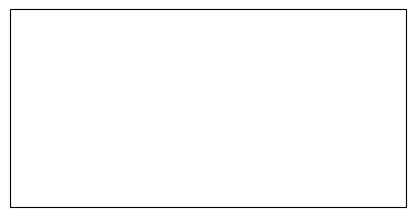

In [97]:
plot_regional_importance(master_phi_matrix, real_lat, real_lon, readable_variables)

In [ ]:
def plot_regional_importance_by_years(master_phi_matrix, metadata_df, lat, lon, 
                                      var_list, year_start, year_end):
    """
    metadata_df: DataFrame containing 'start_year' and 'end_year' and 'combo_idx'
    year_start: The start year of the combo you want to plot
    year_end: The end year of the combo you want to plot
    """

    match = metadata_df[(metadata_df['early'] == year_start) & 
                        (metadata_df['late'] == year_end)]
    
    if match.empty:
        print(f"Error: No combo found for {year_start}-{year_end}")
        return
    
    combo_idx = match['combo_idx'].values[0]
    print(f"Plotting combo_idx: {combo_idx} for years {year_start}-{year_end}")
    

    phi_data = np.nanmean(master_phi_matrix, axis=(0, 1))



    num_vars = phi_data.shape[2]
    fig = plt.figure(figsize=(10, 3 * num_vars))

    for i in range(num_vars):
        ax = fig.add_subplot(num_vars, 1, i + 1, projection=ccrs.PlateCarree())
        data_v = phi_data[:, :, i]

        if data_v.shape[1] != len(lon):
            print(f"Mismatch! data_v has {data_v.shape[1]} columns, but lon has {len(lon)}")
        

        v_limit = np.max(np.abs(data_v))
        if v_limit == 0: v_limit = 1.0 
        
        samplep, lonp = add_cyclic_point(data_v, coord=lon)
        

        cs = ax.contourf(lonp, lat, samplep, cmap="coolwarm", 
                         levels=np.linspace(-v_limit, v_limit, 21), 
                         extend='both', transform=ccrs.PlateCarree())
        
        ax.coastlines()
        ax.set_title(f'Importance: {var_list[i]} ({year_start}-{year_end})', fontsize=16)
        plt.colorbar(cs, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)

    plt.tight_layout()
    plt.show()

In [44]:
metadata_df.columns

Index(['combo_idx', 'scenario', 'early', 'late'], dtype='object')

Plotting combo_idx: 11 for years 2025-2075


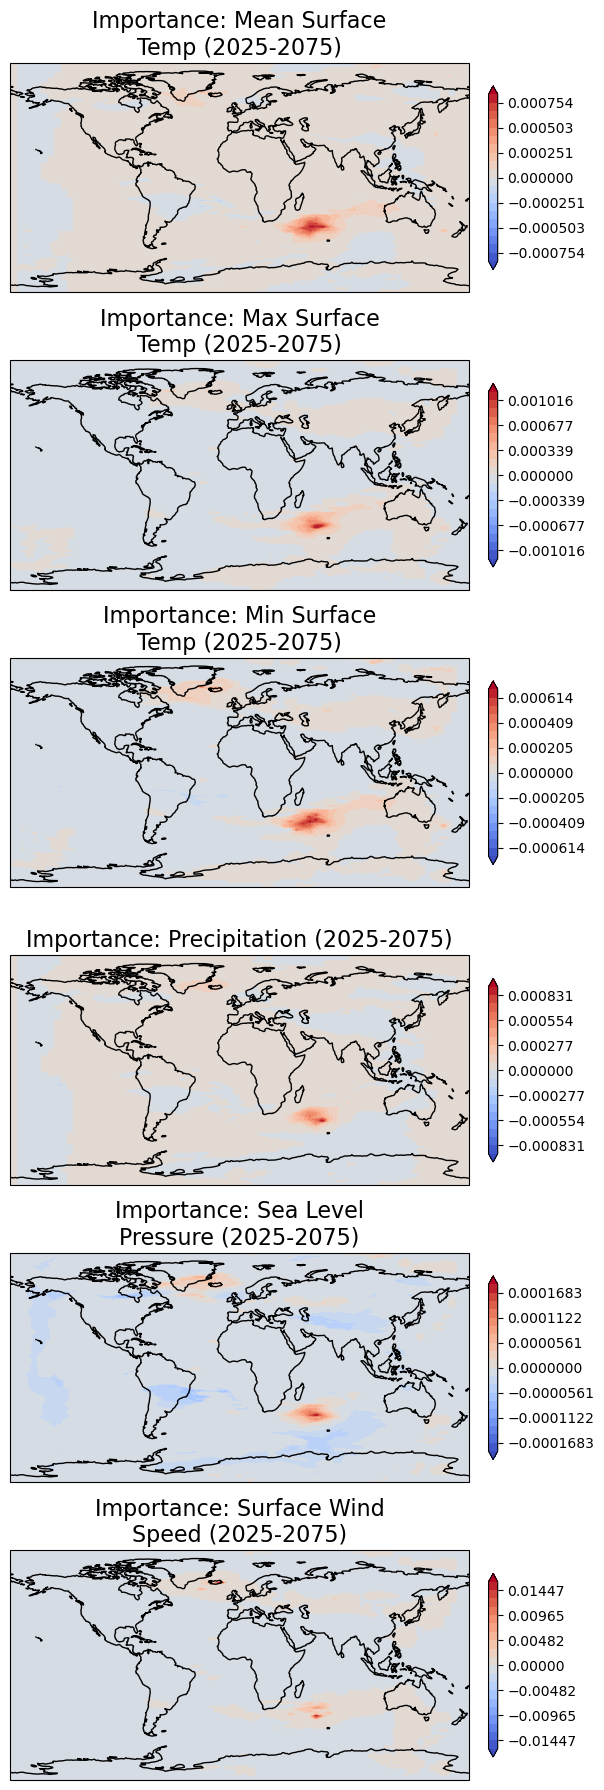

In [ ]:
plot_regional_importance_by_years(
    master_phi_matrix, 
    metadata_df, 
    real_lat, 
    real_lon, 
    readable_variables, 
    year_start=2025, 
    year_end=2075
)